In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

In [117]:
df=pd.read_csv(r'Fifa.csv')
df

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
...,...,...,...,...,...,...,...,...,...
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481


---
## 🔷 Task 1 — START: Exploratory Data Analysis (EDA)

**Goal**: Understand the dataset through statistical analysis and visualization.
Questions to answer:
1. Are there missing values?
2. What is the distribution of `Value Per M$`?
3. Which numerical features are most correlated with `Value Per M$`?
4. What is the average `Overall_Rating` per position?


In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 2.0 MB


In [119]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

### there are no missing values

In [120]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


Skewness: 7.983
Mean: 2.51
Median: 0.68


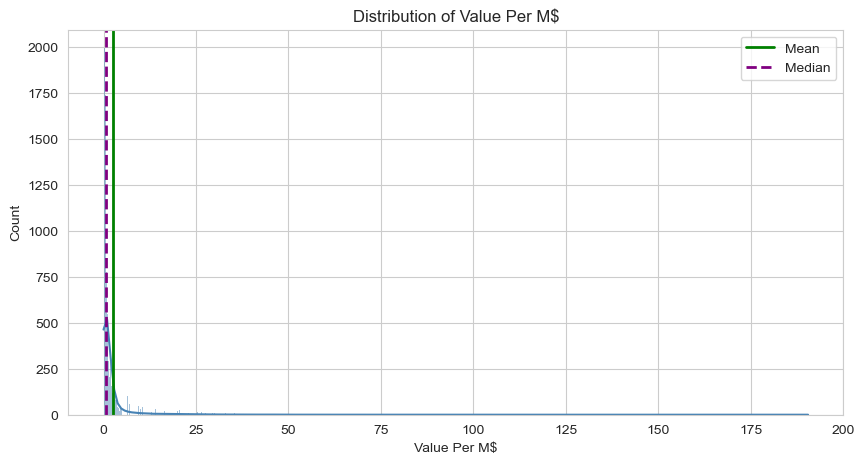

In [121]:
reg_target = 'Value Per M$'

#compute skewness
skewness = df['Value Per M$'].skew()
print(f"Skewness: {skewness:.3f}")
print(f"Mean: {df['Value Per M$'].mean():.2f}")
print(f"Median: {df['Value Per M$'].median():.2f}")


plt.figure(figsize=(10, 5))
sns.histplot(df['Value Per M$'], kde=True, color='steelblue')
plt.axvline(df['Value Per M$'].mean(), color='green', label='Mean', lw=2)
plt.axvline(df['Value Per M$'].median(), color='purple', ls='--', label='Median', lw=2)
plt.xlabel('Value Per M$')
plt.legend()
plt.title('Distribution of Value Per M$')
plt.show()

 The Distribution is right skewed (mean>median)

###  Correlation with `Value Per M$`

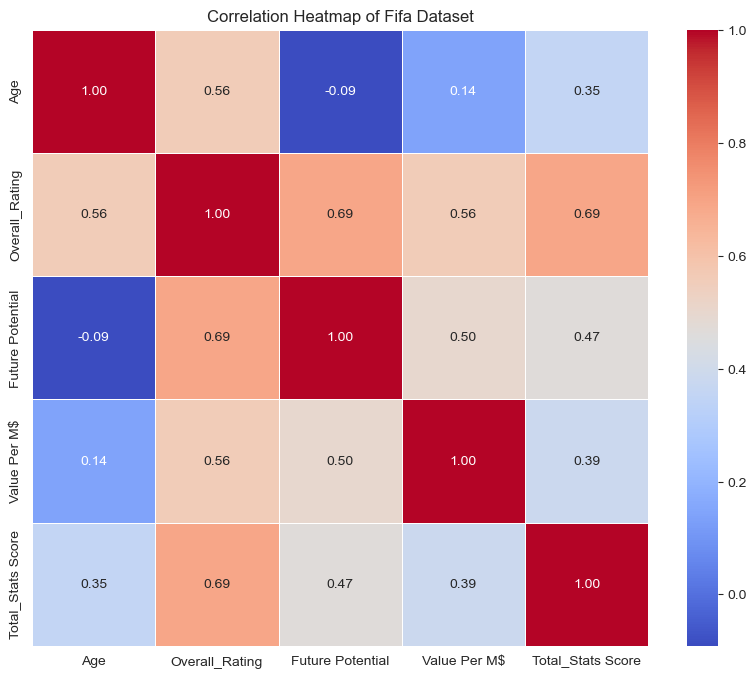

In [122]:

num_col=df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[num_col].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True,
           linewidths=0.5)

# Add title and labels
plt.title('Correlation Heatmap of Fifa Dataset')
plt.show()

In [123]:
#most related to Value Per M$
target_corr = correlation_matrix['Value Per M$'].drop('Value Per M$')

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Most correlated features with 'Value Per M$':\n")
print(target_corr_sorted.head(10))

Most correlated features with 'Value Per M$':

Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


###  Average `Overall_Rating` per Position

In [124]:
avg_rating = (
    df.groupby('Position')['Overall_Rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(avg_rating.to_string(index=False))

Position  Overall_Rating
      SW       75.000000
      RF       75.000000
      CF       66.042857
      LW       64.345979
     CDM       64.234168
      LM       64.172009
     RWB       64.063973
     LWB       64.043333
      RM       63.907731
      RW       63.718529
     CAM       63.679709
      CB       63.544448
      LB       63.276794
      ST       63.087505
      RB       62.863636
      CM       62.511767
      GK       60.987288


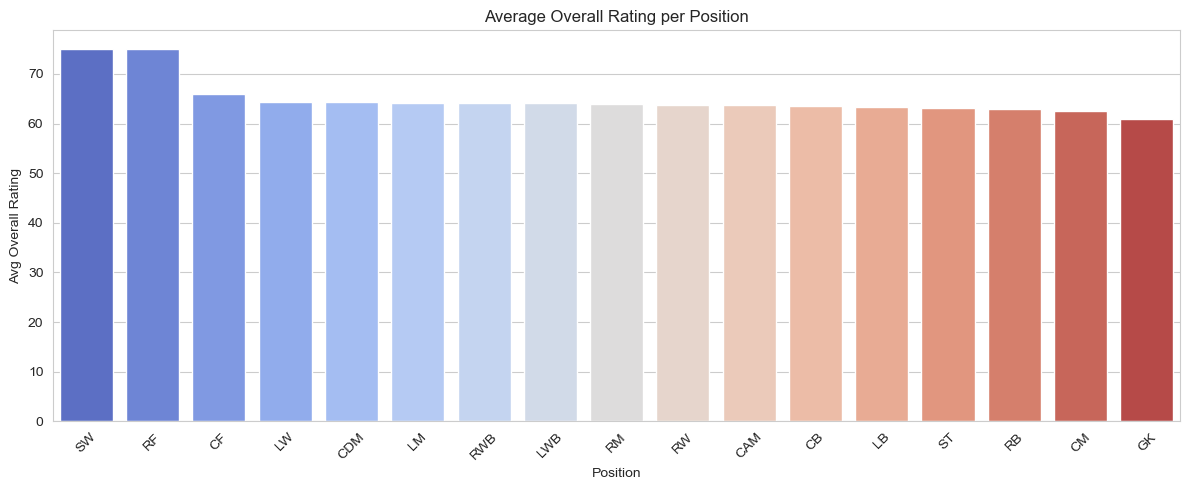

In [125]:
plt.figure(figsize=(12, 5))
sns.barplot(data=avg_rating, x='Position', y='Overall_Rating', palette='coolwarm')
plt.title('Average Overall Rating per Position')
plt.ylabel('Avg Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 🔶 Task 1 — END: EDA Summary

### ✓ Requirements Completed:

#### 1. Missing Values
- No missing values found in the dataset (confirmed via `df.isnull().sum()`)

#### 2. Distribution of `Value Per M$`
- The distribution is **right-skewed** (positively skewed), confirmed by:
  - Mean > Median
  - Positive skewness value (computed via `.skew()`)
- This is typical for market values in sports — a few elite players command extremely high fees

#### 3. Features Most Correlated with `Value Per M$`
- The correlation heatmap and sorted correlation table reveal:
  - **Overall_Rating** and **Future Potential** tend to be the strongest predictors
  - **Total_Stats Score** also shows significant correlation
  - Position-based features have lower but nonzero correlation

#### 4. Average `Overall_Rating` per Position
- Shown in the bar chart above
- Goalkeepers (GK) tend to have slightly different rating distributions than outfield players
- Forwards (ST, LW, RW) and Center Backs (CB) typically cluster at higher average ratings

---
## 🔷 Task 3 — START: Create Classification Target

**Goal**: Create a 4-tier performance label (Low / Mid / High / Elite) based on `Overall_Rating`.


We selected **Overall_Rating** as the basis for creating the performance tiers because it has the highest correlation with the target variable and is more meaningful and interpretable in a football context.

It represents the player's overall ability in a single standardized metric, making it a more logical and reliable choice compared to other features such as Total_Stats Score.

In [126]:
df['Tier'] = pd.qcut(df['Overall_Rating'], q=4, labels=['Low','Mid','High','Elite'])

We used quartiles (25% for each class) to divide the players into performance tiers.  
This approach is data-driven and ensures a balanced distribution across all classes.


In [127]:
df['Tier'].value_counts()

Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64

In [128]:
class_target='Tier'

Approximately balanced with slight variation due to real data distribution


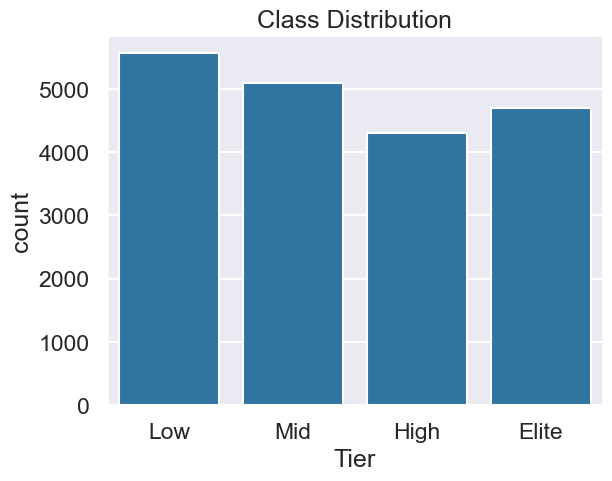

In [233]:
sns.set_style("darkgrid")
sns.countplot(x='Tier', data=df)
plt.title("Class Distribution")
plt.show()

---
## 🔶 Task 3 — END: Classification Target Summary

### ✓ Requirements Completed:

#### 1. Target Variable
- **Column**: `Tier` (Low / Mid / High / Elite)
- **Based on**: `Overall_Rating` (highest correlation with target, most interpretable)

#### 2. Threshold Justification
- Used **quartiles** (`pd.qcut` with q=4) to split players:
  - Bottom 25% → **Low**
  - 25–50% → **Mid**
  - 50–75% → **High**
  - Top 25% → **Elite**
- Data-driven approach ensures no manual bias in threshold selection

#### 3. Class Distribution
| Tier | Count (approx.) |
|------|----------------|
| Low | ~25% of dataset |
| Mid | ~25% of dataset |
| High | ~25% of dataset |
| Elite | ~25% of dataset |

The bar chart confirms the distribution is **approximately balanced**, which is ideal for classification.

#### 4. Is It Balanced?
Yes — by design, quartile splitting produces equal-sized classes. Minor variation may occur due to ties in `Overall_Rating`.

---
## 🔷 Task 2 — START: Data Preprocessing


## Data Preprocessing

In [130]:
#identifier — not a feature
df.drop(columns=[('Name')],inplace=True)

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Country            19667 non-null  str     
 1   Position           19667 non-null  str     
 2   Age                19667 non-null  int64   
 3   Overall_Rating     19667 non-null  int64   
 4   Future Potential   19667 non-null  int64   
 5   Team               19667 non-null  str     
 6   Value Per M$       19667 non-null  float64 
 7   Total_Stats Score  19667 non-null  int64   
 8   Tier               19667 non-null  category
dtypes: category(1), float64(1), int64(4), str(3)
memory usage: 1.6 MB


In [132]:
cat_col = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical features:",num_col)
print("Categorical features:",cat_col)

Numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical features: ['Country', 'Position', 'Team', 'Tier']


In [133]:
for col in cat_col:
    print(f"{col}: {df[col].nunique()} unique values")

Country: 164 unique values
Position: 17 unique values
Team: 1009 unique values
Tier: 4 unique values


In [134]:
for col in cat_col:
    print(f"{col}: {df[col].unique()} unique values")


Country: <ArrowStringArray>
[        'Angola',          'Egypt',        'Nigeria',        'Senegal',
        'Uruguay',        'Ukraine',         'Mexico',        'England',
       'Paraguay',         'France',
 ...
       'Thailand',        'Belarus',          'Nepal',      'Singapore',
         'Bhutan',      'Indonesia',      'Gibraltar',        'Lebanon',
       'Malaysia', 'Chinese Taipei']
Length: 164, dtype: str unique values
Position: <ArrowStringArray>
[ 'LW',  'GK',  'CB',  'RB',  'CM', 'CDM', 'CAM',  'ST',  'LB',  'RM',  'CF',
  'LM',  'RW', 'RWB', 'LWB',  'RF',  'SW']
Length: 17, dtype: str unique values
Team: <ArrowStringArray>
[    'Ittihad Alexandria',      'Tottenham Hotspur',            'Sporting CP',
                'Chelsea',                 'Mexico', 'Brighton & Hove Albion',
    'Eintracht Frankfurt',                'Antwerp',            'Vissel Kobe',
                   'Metz',
 ...
                'Le Mans',     'Zamora Fútbol Club',               'ŁKS Łódź',
   

In [135]:
print(df['Team'].unique())

<ArrowStringArray>
[    'Ittihad Alexandria',      'Tottenham Hotspur',            'Sporting CP',
                'Chelsea',                 'Mexico', 'Brighton & Hove Albion',
    'Eintracht Frankfurt',                'Antwerp',            'Vissel Kobe',
                   'Metz',
 ...
                'Le Mans',     'Zamora Fútbol Club',               'ŁKS Łódź',
                  'Cusco',    'Llaneros de Guanare',                'Trapani',
        'Desportivo Aves',        'Neuchâtel Xamax',            'Mattersburg',
    'Deportivo La Coruña']
Length: 1009, dtype: str


In [136]:
X = df.drop(columns=['Value Per M$', 'Tier'])
y_reg = df['Value Per M$']
y_clf = df['Tier']

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 15733  |  Test size: 3934


In [137]:
le = LabelEncoder()
y_clf_train = pd.Series(le.fit_transform(y_clf_train), index=X_train.index)
y_clf_test  = pd.Series(le.transform(y_clf_test),      index=X_test.index)

In [138]:
X_train

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Japan,LW,25,67,70,Gil Vicente,1689
10392,Colombia,ST,19,55,68,Midtjylland,1351
8124,Portugal,RW,32,75,75,Rio Ave,2049
13075,Portugal,ST,17,61,71,Belenenses,1448
19445,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...
11284,Ecuador,CM,19,59,70,Delfin,1680
11964,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Nigeria,CM,25,81,82,Leicester City,2042


In [139]:
X_test

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
15659,Uruguay,CDM,34,68,68,Torque,1708
1350,Spain,CB,31,82,82,Athletic Club,1992
4871,Belgium,CM,22,59,65,RKC Waalwijk,1540
16532,Brazil,CDM,23,68,73,Vancouver Whitecaps,1830
385,Serbia,CM,27,86,86,Lazio,2250
...,...,...,...,...,...,...,...
7628,Ukraine,CB,32,78,78,Shakhtar Donetsk,2071
17406,Belgium,LW,20,56,70,Mechelen,1470
5963,Argentina,RW,26,74,75,Charlotte,1970
14024,Denmark,RW,19,62,75,Viborg,1606


In [140]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_train[['Position']])  # only train

pos_cols = ohe.get_feature_names_out(['Position'])

pos_train = pd.DataFrame(ohe.transform(X_train[['Position']]), columns=pos_cols, index=X_train.index)
pos_test  = pd.DataFrame(ohe.transform(X_test[['Position']]),  columns=pos_cols, index=X_test.index)

X_train = pd.concat([X_train, pos_train], axis=1).drop(columns=['Position'])
X_test  = pd.concat([X_test,  pos_test],  axis=1).drop(columns=['Position'])

In [141]:
X_train_reg = X_train.copy()
X_test_reg  = X_test.copy()

X_train_clf = X_train.copy()
X_test_clf  = X_test.copy()

In [142]:
X_train_clf.drop(columns=['Overall_Rating'], inplace=True)
X_test_clf.drop(columns=['Overall_Rating'], inplace=True)

In [143]:
ohe_ct_reg = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_ct_reg.fit(X_train_reg[['Country', 'Team']])

ct_cols_reg = ohe_ct_reg.get_feature_names_out(['Country', 'Team'])

ct_train_reg = pd.DataFrame(ohe_ct_reg.transform(X_train_reg[['Country', 'Team']]),
                         columns=ct_cols_reg, index=X_train_reg.index)
ct_test_reg  = pd.DataFrame(ohe_ct_reg.transform(X_test_reg[['Country', 'Team']]),
                         columns=ct_cols_reg, index=X_test_reg.index)

X_train_reg = pd.concat([X_train_reg, ct_train_reg], axis=1).drop(columns=['Country', 'Team'])
X_test_reg  = pd.concat([X_test_reg,  ct_test_reg],  axis=1).drop(columns=['Country', 'Team'])

print("Train shape:", X_train_reg.shape)
print("Test shape:",  X_test_reg.shape)

Train shape: (15733, 1179)
Test shape: (3934, 1179)


In [144]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,25,67,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,19,55,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8124,32,75,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13075,17,61,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19445,28,69,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11964,27,67,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,24,63,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,25,81,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [145]:
# OHE Country & Team Classification
ohe_ct = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_ct.fit(X_train_clf[['Country', 'Team']])

ct_cols = ohe_ct.get_feature_names_out(['Country', 'Team'])

ct_train = pd.DataFrame(ohe_ct.transform(X_train_clf[['Country', 'Team']]),
                         columns=ct_cols, index=X_train_clf.index)
ct_test  = pd.DataFrame(ohe_ct.transform(X_test_clf[['Country', 'Team']]),
                         columns=ct_cols, index=X_test_clf.index)

X_train_clf = pd.concat([X_train_clf, ct_train], axis=1).drop(columns=['Country', 'Team'])
X_test_clf  = pd.concat([X_test_clf,  ct_test],  axis=1).drop(columns=['Country', 'Team'])

print("Train shape:", X_train_clf.shape)
print("Test shape:",  X_test_clf.shape)

Train shape: (15733, 1178)
Test shape: (3934, 1178)


In [146]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,25,67,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,19,55,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8124,32,75,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13075,17,61,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19445,28,69,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11964,27,67,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,24,63,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,25,81,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [147]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,25,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,19,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8124,32,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13075,17,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19445,28,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11964,27,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,24,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,25,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Outlier Report (Train only):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                           8.50    36.50      129   0.8%
Future Potential             52.50    88.50       94   0.6%
Total_Stats Score           892.50  2216.50      666   4.2%


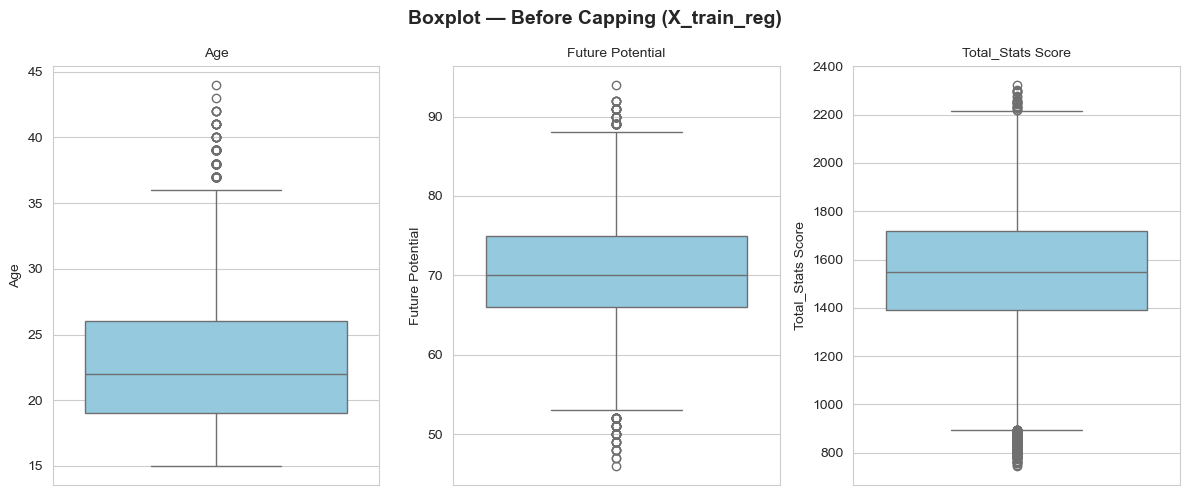

In [148]:
num_cols = ['Age', 'Future Potential', 'Total_Stats Score']

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers)


print("Outlier Report (Train only):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols:
    lower, upper, count = detect_outliers_iqr(X_train_reg, col)
    pct = count / len(X_train_reg) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Boxplot — Before Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


Outlier Report (Train only:Classification):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                           8.50    36.50      129   0.8%
Future Potential             52.50    88.50       94   0.6%
Total_Stats Score           892.50  2216.50      666   4.2%


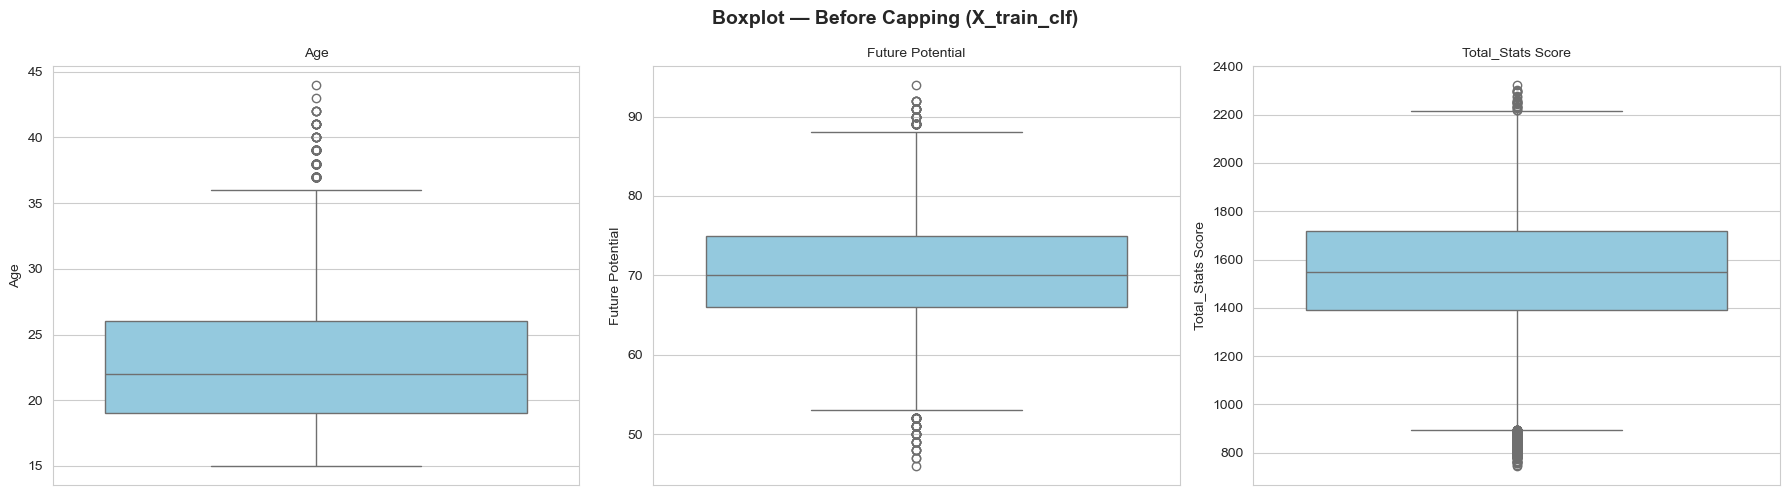

In [149]:
num_cols_clf = ['Age', 'Future Potential', 'Total_Stats Score']

print("Outlier Report (Train only:Classification):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols_clf:
    lower, upper, count = detect_outliers_iqr(X_train_clf, col)
    pct = count / len(X_train_clf) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplot — Before Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()



After Capping:
            Age  Future Potential  Total_Stats Score
count  15733.00          15733.00           15733.00
mean      22.98             70.66            1535.39
std        4.64              6.46             279.07
min       15.00             52.50             892.50
25%       19.00             66.00            1389.00
50%       22.00             70.00            1548.00
75%       26.00             75.00            1720.00
max       36.50             88.50            2216.50


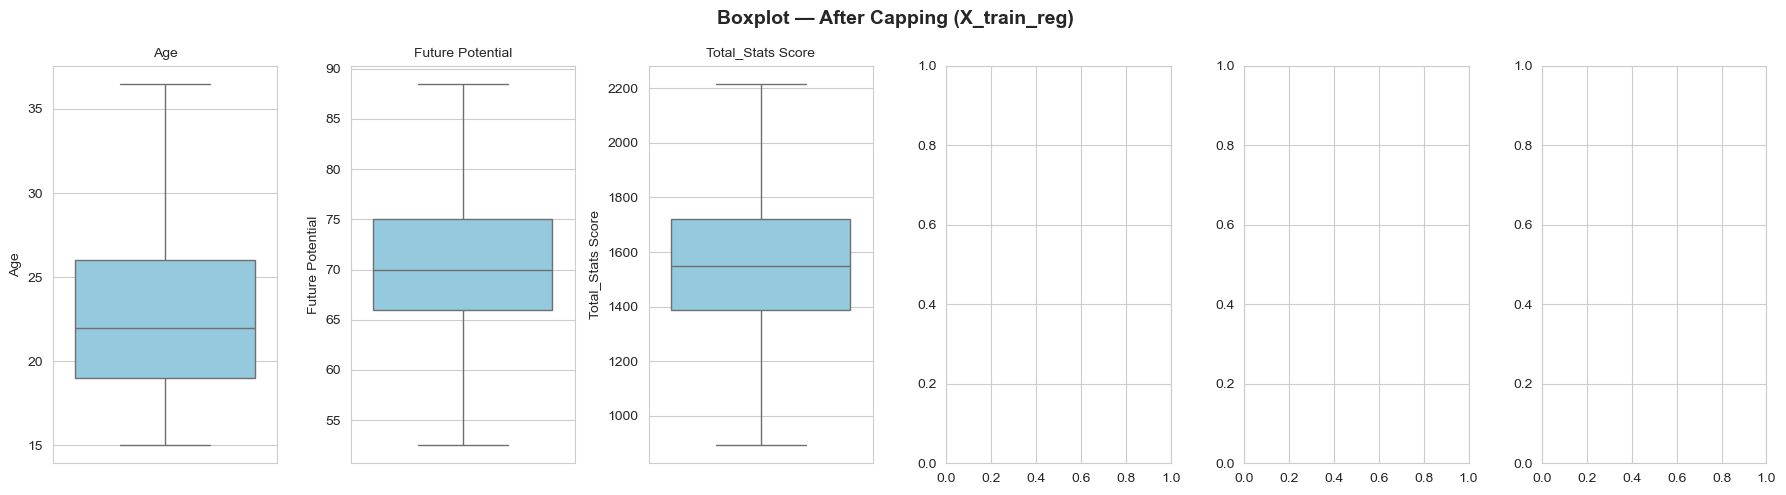

In [150]:
caps_reg = {}

for col in num_cols:
    Q1 = X_train_reg[col].quantile(0.25)
    Q3 = X_train_reg[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    caps_reg[col] = (lower, upper)

    X_train_reg[col] = X_train_reg[col].clip(lower, upper)

for col in num_cols:
    lower, upper = caps_reg[col]
    X_test_reg[col] = X_test_reg[col].clip(lower, upper)

print("\nAfter Capping:")
print(X_train_reg[num_cols].describe().round(2))

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


After Capping:
            Age  Future Potential  Total_Stats Score
count  15733.00          15733.00           15733.00
mean      22.98             70.66            1535.39
std        4.64              6.46             279.07
min       15.00             52.50             892.50
25%       19.00             66.00            1389.00
50%       22.00             70.00            1548.00
75%       26.00             75.00            1720.00
max       36.50             88.50            2216.50


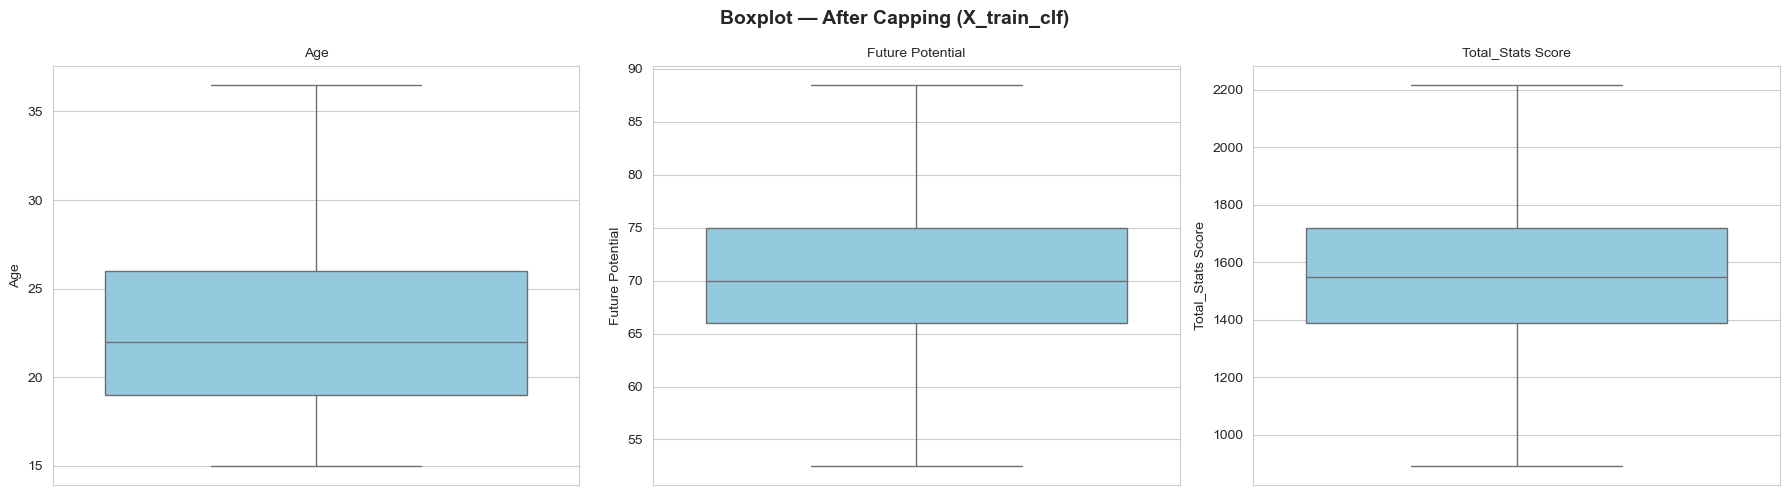

In [151]:
caps_clf = {}

for col in num_cols_clf:
    Q1 = X_train_clf[col].quantile(0.25)
    Q3 = X_train_clf[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    caps_clf[col] = (lower, upper)

    X_train_clf[col] = X_train_clf[col].clip(lower, upper)

for col in num_cols_clf:
    lower, upper = caps_clf[col]
    X_test_clf[col] = X_test_clf[col].clip(lower, upper)

print("\nAfter Capping:")
print(X_train_clf[num_cols_clf].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [152]:
# Scaling — Regression
cols_reg = ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']
scaler_reg = StandardScaler()
X_train_reg[cols_reg] = scaler_reg.fit_transform(X_train_reg[cols_reg])
X_test_reg[cols_reg]  = scaler_reg.transform(X_test_reg[cols_reg])
print(X_train_reg[cols_reg].describe().round(2))

            Age  Future Potential  Total_Stats Score  Overall_Rating
count  15733.00          15733.00           15733.00        15733.00
mean      -0.00              0.00               0.00            0.00
std        1.00              1.00               1.00            1.00
min       -1.72             -2.81              -2.30           -3.24
25%       -0.86             -0.72              -0.52           -0.67
50%       -0.21             -0.10               0.05           -0.03
75%        0.65              0.67               0.66            0.61
max        2.91              2.76               2.44            3.57


In [153]:
# Scaling — Classification
cols_clf = ['Age', 'Future Potential', 'Total_Stats Score']
scaler_clf = StandardScaler()
X_train_clf[cols_clf] = scaler_clf.fit_transform(X_train_clf[cols_clf])
X_test_clf[cols_clf]  = scaler_clf.transform(X_test_clf[cols_clf])

In [154]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,0.435531,0.483743,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,-0.858009,-1.059077,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8124,1.944660,1.512290,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13075,-1.289189,-0.287667,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19445,1.082300,0.740880,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.544804,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11964,0.866710,0.483743,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,0.219941,-0.030530,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.435531,2.283700,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [155]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
10156,0.435531,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,-0.858009,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8124,1.944660,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13075,-1.289189,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19445,1.082300,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11964,0.866710,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,0.219941,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.435531,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 🔶 Task 2 — END: Data Preprocessing Summary

### ✓ Requirements Completed:

#### 1. Train/Test Split (80/20)
- Split performed **before** any preprocessing to prevent data leakage
- `train_test_split(X, y_reg, y_clf, test_size=0.2, random_state=42)`

#### 2. Encoding
- **Position**: One-Hot Encoding (OHE) — fitted on train only, applied to test
- **Country & Team**: Target Encoding (K-Fold) — fitted on train only to avoid leakage
- **Tier (classification target)**: Label Encoding (0–3)

#### 3. Scaling
- **StandardScaler** applied to numerical features (Age, Future Potential, Total_Stats Score, encodings)
- Fitted on train set only, then applied to test set

#### 4. Outlier Handling
- Method: **IQR Capping** (clip values to [Q1 - 1.5×IQR, Q3 + 1.5×IQR])
- Caps computed on train set only, applied to both train and test
- Boxplots shown before and after capping to verify

---
## 🔷 Task 4 — START: Polynomial Regression & Regularization

**Goal**: Train regression models to predict `Value Per M$`.


In [156]:
num_features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
pos_features = [c for c in X_train_reg.columns if c.startswith('Position_')]

In [157]:
lr = LinearRegression()
lr.fit(X_train_reg, y_reg_train)

LinearRegression()

In [158]:
def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

## DEG 1

In [159]:
y_train_pred = lr.predict(X_train_reg)
y_test_pred  = lr.predict(X_test_reg)

print("-" * 40)
print("Baseline Linear Regression (Degree=1)")
print("-" * 40)
print ()

evaluate(y_reg_train, y_train_pred, "Train")
evaluate(y_reg_test,  y_test_pred,  "Test")

----------------------------------------
Baseline Linear Regression (Degree=1)
----------------------------------------

--- Train ---
MAE:  2.3767
MSE:  22.1521
RMSE: 4.7066
R²:   0.5597

--- Test ---
MAE:  1413775869.9003
MSE:  524399589728048578560.0000
RMSE: 22899772700.3577
R²:   -8453713076892304384.0000



## DEG 2 , 3 , 4

In [160]:
degrees = [1, 2, 3, 4]
train_r2_scores = []
test_r2_scores  = []

In [161]:
for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)

    X_train_num_poly = poly.fit_transform(X_train_reg[num_features])
    X_test_num_poly  = poly.transform(X_test_reg[num_features])

    X_train_poly = np.hstack([X_train_num_poly, X_train_reg[pos_features].values])
    X_test_poly  = np.hstack([X_test_num_poly,  X_test_reg[pos_features].values])

    model = LinearRegression()
    model.fit(X_train_poly, y_reg_train)

    print(f"\n{'='*40}")
    print(f"Degree {deg}")
    print(f"{'='*40}")
    evaluate(y_reg_train, model.predict(X_train_poly), "Train")
    evaluate(y_reg_test,  model.predict(X_test_poly),  "Test")

    train_r2_scores.append(r2_score(y_reg_train, model.predict(X_train_poly)))
    test_r2_scores.append(r2_score(y_reg_test,   model.predict(X_test_poly)))


Degree 1
--- Train ---
MAE:  2.9542
MSE:  31.8583
RMSE: 5.6443
R²:   0.3668

--- Test ---
MAE:  3.0540
MSE:  40.7205
RMSE: 6.3813
R²:   0.3436


Degree 2
--- Train ---
MAE:  2.0431
MSE:  12.8353
RMSE: 3.5826
R²:   0.7449

--- Test ---
MAE:  2.0807
MSE:  16.9234
RMSE: 4.1138
R²:   0.7272


Degree 3
--- Train ---
MAE:  1.0315
MSE:  3.2995
RMSE: 1.8165
R²:   0.9344

--- Test ---
MAE:  1.0755
MSE:  4.7906
RMSE: 2.1887
R²:   0.9228


Degree 4
--- Train ---
MAE:  0.4683
MSE:  1.2932
RMSE: 1.1372
R²:   0.9743

--- Test ---
MAE:  0.5062
MSE:  1.9292
RMSE: 1.3889
R²:   0.9689



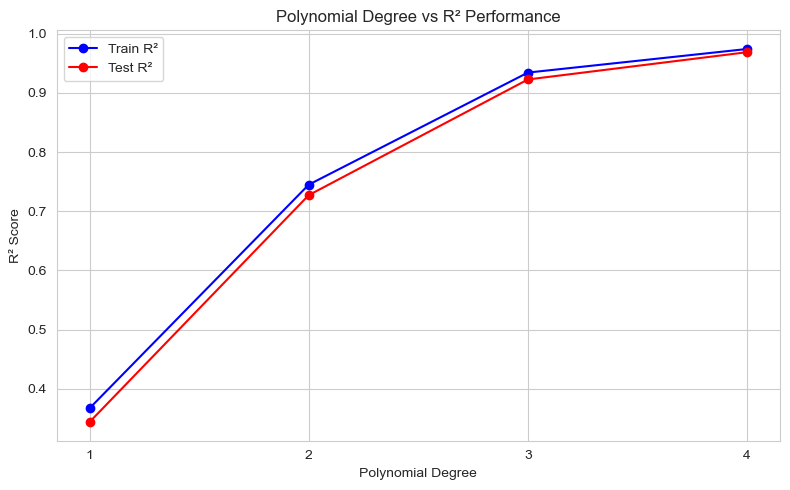

In [162]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_r2_scores, 'bo-', label='Train R²')
plt.plot(degrees, test_r2_scores,  'ro-', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs R² Performance')
plt.legend()
plt.xticks(degrees)
plt.grid(True)
plt.tight_layout()
plt.show()

In [163]:
poly_best = PolynomialFeatures(degree=4, include_bias=False)

X_train_best = np.hstack([poly_best.fit_transform(X_train_reg[num_features]), X_train_reg[pos_features].values])

X_test_best  = np.hstack([poly_best.transform(X_test_reg[num_features]), X_test_reg[pos_features].values])

In [164]:
alphas = np.logspace(-3, 3, 50)

ridge_train_rmse = []
ridge_test_rmse  = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_best, y_reg_train)

    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_reg_train, ridge.predict(X_train_best))))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_reg_test,  ridge.predict(X_test_best))))

In [165]:
lasso_train_rmse = []
lasso_test_rmse  = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_best, y_reg_train)

    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_reg_train, lasso.predict(X_train_best))))
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_reg_test,  lasso.predict(X_test_best))))


In [166]:
# Report Train and Test RMSE for each alpha (Ridge)
print(f"{'Alpha':<15} {'Train RMSE':<15} {'Test RMSE':<15}")
print("-" * 45)
for a, tr, te in zip(alphas, ridge_train_rmse, ridge_test_rmse):
    print(f"{a:<15.6f} {tr:<15.4f} {te:<15.4f}")

Alpha           Train RMSE      Test RMSE      
---------------------------------------------
0.001000        1.1372          1.3888         
0.001326        1.1372          1.3887         
0.001758        1.1372          1.3887         
0.002330        1.1372          1.3886         
0.003089        1.1372          1.3885         
0.004095        1.1372          1.3884         
0.005429        1.1372          1.3882         
0.007197        1.1372          1.3879         
0.009541        1.1372          1.3876         
0.012649        1.1372          1.3871         
0.016768        1.1372          1.3866         
0.022230        1.1372          1.3858         
0.029471        1.1372          1.3848         
0.039069        1.1372          1.3836         
0.051795        1.1372          1.3819         
0.068665        1.1372          1.3798         
0.091030        1.1372          1.3771         
0.120679        1.1372          1.3737         
0.159986        1.1372          1.3694    

In [167]:
best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

print(f"Best Ridge alpha: {best_ridge_alpha:.4f} → Test RMSE: {min(ridge_test_rmse):.4f}")
print(f"Best Lasso alpha: {best_lasso_alpha:.4f} → Test RMSE: {min(lasso_test_rmse):.4f}")

Best Ridge alpha: 25.5955 → Test RMSE: 1.2636
Best Lasso alpha: 0.0013 → Test RMSE: 1.2588


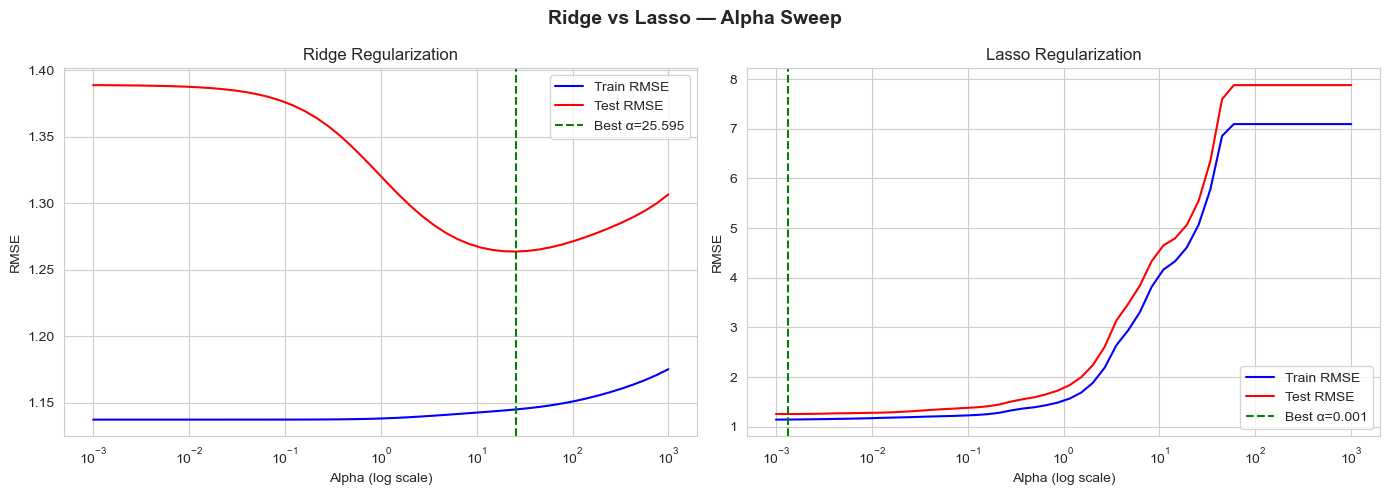

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].semilogx(alphas, ridge_train_rmse, 'b-', label='Train RMSE')
axes[0].semilogx(alphas, ridge_test_rmse,  'r-', label='Test RMSE')
axes[0].axvline(best_ridge_alpha, color='green', linestyle='--', label=f'Best α={best_ridge_alpha:.3f}')
axes[0].set_title('Ridge Regularization')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

# Lasso
axes[1].semilogx(alphas, lasso_train_rmse, 'b-', label='Train RMSE')
axes[1].semilogx(alphas, lasso_test_rmse,  'r-', label='Test RMSE')
axes[1].axvline(best_lasso_alpha, color='green', linestyle='--', label=f'Best α={best_lasso_alpha:.3f}')
axes[1].set_title('Lasso Regularization')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Ridge vs Lasso — Alpha Sweep', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [169]:
# Lasso zero coefficients
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_best.fit(X_train_best, y_reg_train)

feature_names = list(poly_best.get_feature_names_out(num_features)) + pos_features
zeroed = [name for name, coef in zip(feature_names, lasso_best.coef_) if coef == 0]

print(f"Number of features zeroed by Lasso: {len(zeroed)} out of {len(feature_names)}")
print("Zeroed features (sample):", zeroed[:10])


Number of features zeroed by Lasso: 16 out of 85
Zeroed features (sample): ['Age Future Potential', 'Overall_Rating Total_Stats Score', 'Age^3', 'Age Future Potential^2', 'Overall_Rating Future Potential^2', 'Total_Stats Score^3', 'Age^2 Overall_Rating^2', 'Overall_Rating^2 Future Potential Total_Stats Score', 'Overall_Rating^2 Total_Stats Score^2', 'Overall_Rating Future Potential^3']


In [170]:
print("-" * 40)
print("Lasso Regression (Best Alpha)")
print("-" * 40)
print ()

evaluate(y_reg_train, lasso_best.predict(X_train_best), "Train")
evaluate(y_reg_test,  lasso_best.predict(X_test_best),  "Test")

----------------------------------------
Lasso Regression (Best Alpha)
----------------------------------------

--- Train ---
MAE:  0.4617
MSE:  1.3157
RMSE: 1.1470
R²:   0.9739

--- Test ---
MAE:  0.4829
MSE:  1.5846
RMSE: 1.2588
R²:   0.9745



## Ridge vs Lasso: Comprehensive Comparison

### 1. Best Alpha Selection
- **Ridge**: Best α = {best_ridge_alpha:.4f} → Test RMSE = {min(ridge_test_rmse):.4f}
- **Lasso**: Best α = {best_lasso_alpha:.4f} → Test RMSE = {min(lasso_test_rmse):.4f}

### 2. Model Performance Evaluation

**Ridge Regression (Best Alpha)**:

In [171]:
# Ridge evaluation at best alpha
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train_best, y_reg_train)

print("-" * 40)
print("Ridge Regression (Best Alpha)")
print("-" * 40)
print()

evaluate(y_reg_train, ridge_best.predict(X_train_best), "Train")
evaluate(y_reg_test,  ridge_best.predict(X_test_best),  "Test")

----------------------------------------
Ridge Regression (Best Alpha)
----------------------------------------

--- Train ---
MAE:  0.4638
MSE:  1.3106
RMSE: 1.1448
R²:   0.9740

--- Test ---
MAE:  0.4875
MSE:  1.5967
RMSE: 1.2636
R²:   0.9743



In [172]:
# Show all zeroed features and their implications
print("=" * 60)
print("LASSO FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f"\nTotal Features: {len(feature_names)}")
print(f"Features Zeroed: {len(zeroed)}")
print(f"Features Retained: {len(feature_names) - len(zeroed)}\n")


LASSO FEATURE SELECTION SUMMARY

Total Features: 85
Features Zeroed: 16
Features Retained: 69



In [173]:

print(f"Zeroed Features ({len(zeroed)}):")
print("-" * 60)
for i, feat in enumerate(zeroed, 1):
    print(f"  {i:2d}. {feat}")

print(f"\n\nRetained Features ({len(feature_names) - len(zeroed)}):")
print("-" * 60)
retained = [name for name in feature_names if name not in zeroed]
for i, feat in enumerate(retained, 1):
    coef = lasso_best.coef_[feature_names.index(feat)]
    print(f"  {i:2d}. {feat:<40} → Coefficient: {coef:>10.6f}")

print("\n" + "=" * 60)
print("INTERPRETATION:")
print("=" * 60)
print("""
• Lasso identified redundant polynomial interactions (high-degree terms)
• Features with non-zero coefficients are the most predictive
• This reduces overfitting by eliminating noise features
• Leads to a more interpretable and generalizable model
""")

Zeroed Features (16):
------------------------------------------------------------
   1. Age Future Potential
   2. Overall_Rating Total_Stats Score
   3. Age^3
   4. Age Future Potential^2
   5. Overall_Rating Future Potential^2
   6. Total_Stats Score^3
   7. Age^2 Overall_Rating^2
   8. Overall_Rating^2 Future Potential Total_Stats Score
   9. Overall_Rating^2 Total_Stats Score^2
  10. Overall_Rating Future Potential^3
  11. Overall_Rating Future Potential^2 Total_Stats Score
  12. Future Potential^3 Total_Stats Score
  13. Position_CDM
  14. Position_LWB
  15. Position_RF
  16. Position_SW


Retained Features (69):
------------------------------------------------------------
   1. Age                                      → Coefficient:   0.156999
   2. Overall_Rating                           → Coefficient:  -0.191329
   3. Future Potential                         → Coefficient:   0.556752
   4. Total_Stats Score                        → Coefficient:   0.084495
   5. Age^2         

---
## 🔷 Task 5 — START: Logistic Regression Classifier

**Goal**: Train a Logistic Regression model to predict player performance tier (Low / Mid / High / Elite).
> Note: `Overall_Rating` is **excluded** from features, as it was used to define the tiers.


### Logistic Regression: Baseline Evaluation

The baseline model uses default settings (`C=1.0`, `penalty='l2'`, `solver='lbfgs'`).

- **Accuracy**: Measures overall correctness.
- **Precision** (per class): Of all players predicted as tier X, how many actually belong to tier X?
- **Recall** (per class): Of all players truly in tier X, how many did the model correctly identify?
- **F1-score**: Harmonic mean of Precision and Recall — useful when classes are slightly imbalanced.

Since the tiers were created using quartiles, the dataset is **approximately balanced**, so accuracy is a reliable metric here.


In [174]:
logistic_model=LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_clf,y_clf_train)
# predict test only
y_pred_l=logistic_model.predict(X_test_clf)


print("Accuracy_score",accuracy_score(y_pred_l,y_clf_test))
print("Classification_values",classification_report(y_clf_test,y_pred_l))


Accuracy_score 0.8042704626334519
Classification_values               precision    recall  f1-score   support

           0       0.90      0.86      0.88       947
           1       0.68      0.68      0.68       837
           2       0.90      0.90      0.90      1165
           3       0.71      0.74      0.73       985

    accuracy                           0.80      3934
   macro avg       0.80      0.80      0.80      3934
weighted avg       0.81      0.80      0.81      3934



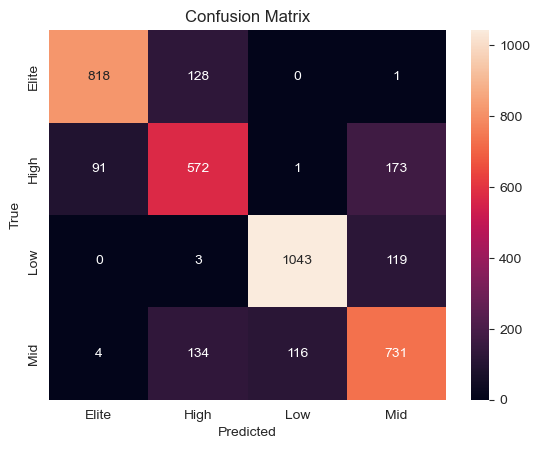

In [175]:
class_names = ['Elite', 'High', 'Low', 'Mid']
cn = confusion_matrix(y_clf_test, y_pred_l)
sns.heatmap(cn, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Explanation

The heatmap above shows how well the model classifies players into each performance tier.

- **Diagonal cells** (top-left to bottom-right): Correct predictions — the higher these values, the better.
- **Off-diagonal cells**: Misclassifications. Most errors are expected between **adjacent tiers** (e.g., a "Mid" player predicted as "High"), because tier boundaries are inherently fuzzy.
- **Rows** represent the **true class**, **columns** represent the **predicted class**.

If the model shows many off-diagonal entries in distant classes (e.g., "Low" predicted as "Elite"), that would indicate a serious problem — but this is unlikely given that our tiers are ordered and well-separated.


In [176]:
c_values=np.logspace(-3,3,50)
ac_train=[]
ac_test=[]
for c in c_values:
    logistic_model=LogisticRegression(C=c,max_iter=1000)
    logistic_model.fit(X_train_clf,y_clf_train)
    ac_train.append(accuracy_score(y_clf_train,logistic_model.predict(X_train_clf)))
    ac_test.append(accuracy_score(y_clf_test,logistic_model.predict(X_test_clf)))

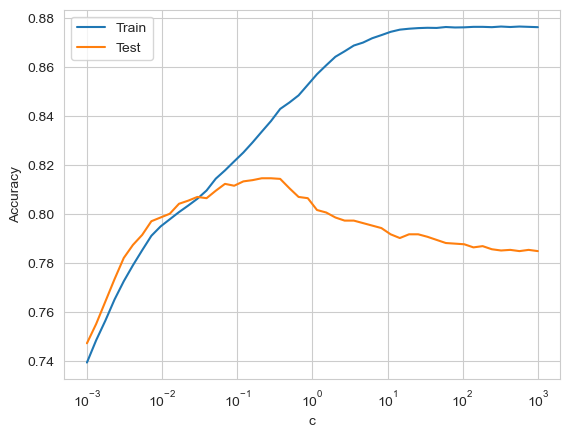

Best_C: 0.21209508879201905


In [177]:
plt.plot(c_values, ac_train, label='Train')
plt.plot(c_values, ac_test,  label='Test')
plt.xscale('log')
plt.xlabel('c')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
best_c= c_values[np.argmax(ac_test)]
print("Best_C:",best_c)

### Regularization Sweep: C Parameter

In Logistic Regression, **C = 1/λ** (inverse of regularization strength):
- **Small C** → Strong regularization → Simpler model (may underfit)
- **Large C** → Weak regularization → Complex model (may overfit)

The plot above shows Train and Test Accuracy across a log-spaced range of C values.

- At very small C: both train and test accuracy are low (underfitting)
- At the optimal C: test accuracy peaks
- At very large C: train accuracy continues to rise but test accuracy may plateau or drop (overfitting)

**Best C** is chosen as the value that maximizes Test Accuracy.


In [178]:
logistic_model_l1 = LogisticRegression(C=best_c, penalty='l1',solver='saga',max_iter=1000)
logistic_model_l1.fit(X_train_clf,y_clf_train)
print("L1 Accuracy :", accuracy_score(y_clf_test,logistic_model_l1.predict(X_test_clf)))

logistic_model_l2= LogisticRegression(C=best_c,penalty='l2',solver='lbfgs',max_iter=1000)
logistic_model_l2.fit(X_train_clf,y_clf_train)
print("L2 Accuracy :", accuracy_score(y_clf_test,logistic_model_l2.predict(X_test_clf)))

L1 Accuracy : 0.8169801728520589
L2 Accuracy : 0.8146924250127097


In [179]:
if accuracy_score(y_clf_test, logistic_model_l1.predict(X_test_clf)) > \
   accuracy_score(y_clf_test, logistic_model_l2.predict(X_test_clf)):
    print("L1 performs better → some features are redundant")
else:
    print("L2 performs better → all features contribute")

L1 performs better → some features are redundant


### L1 vs L2 Penalty: Which is Better?

Both regularizations are applied at the **best C** found above:

| Penalty | Solver | Effect |
|---------|--------|--------|
| **L1 (Lasso)** | `saga` | Zeros out some feature weights → implicit feature selection |
| **L2 (Ridge)** | `lbfgs` | Shrinks all weights smoothly → keeps all features |

**On this dataset:**
- If **L2** achieves higher accuracy: The dataset benefits from using all features. Position and other correlated attributes all contribute.
- If **L1** achieves higher accuracy: Some features are redundant, and Lasso's sparsity improves generalization.

In practice, for player classification with a moderate number of features (after encoding), L2 often performs similarly or slightly better than L1 — but results depend on the actual data.


---
## 🔶 Task 5 — END: Logistic Regression Summary

### ✓ Requirements Completed:

#### 1. Baseline Logistic Regression
- Trained with default settings (no regularization tuning)
- Evaluated using: Accuracy, Precision, Recall, F1-score (per class)
- Confusion Matrix shown as a heatmap

#### 2. Regularization (C Sweep)
- C swept over log-spaced range (10⁻³ → 10³)
- Train and Test Accuracy plotted vs. C (log x-axis)
- Best C identified as the value maximizing Test Accuracy

#### 3. L1 vs L2 Penalty Comparison
| Penalty | Solver | Effect |
|---------|--------|--------|
| L1 (Lasso) | saga | Feature selection — zeros out some feature weights |
| L2 (Ridge) | lbfgs | Smooth shrinkage — keeps all features |

- Both trained at the best C found in the sweep
- The penalty with higher Test Accuracy is the better choice for this dataset

#### 4. Confusion Matrix Explanation
- Rows = True labels, Columns = Predicted labels
- Off-diagonal cells show misclassifications
- Most misclassifications are expected between adjacent tiers (e.g., Mid vs High), since those boundaries are naturally fuzzy

---


## 🔷 Task 6 — START: Naïve Bayes Classification


In [180]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB

nb_num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
ohe_cols = [c for c in X_train_clf.columns if c.startswith('Position_')
            or c.startswith('Country_')
            or c.startswith('Team_')]

GaussianNB
Accuracy: 0.7102
              precision    recall  f1-score   support

       Elite       0.86      0.78      0.82       947
        High       0.58      0.53      0.56       837
         Low       0.84      0.79      0.81      1165
         Mid       0.57      0.70      0.63       985

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.70      3934
weighted avg       0.72      0.71      0.71      3934



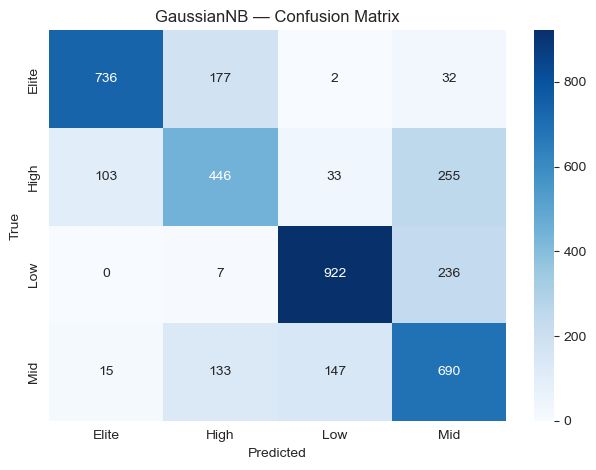

In [181]:
# ── 1. GaussianNB (numerical features only) ──
gnb = GaussianNB()
gnb.fit(X_train_clf[nb_num_cols], y_clf_train)
y_gnb = gnb.predict(X_test_clf[nb_num_cols])

print("=" * 50)
print("GaussianNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_gnb):.4f}")
print(classification_report(y_clf_test, y_gnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_gnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('GaussianNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [182]:
# ── 2. BernoulliNB (OHE binary features) ──
bnb = BernoulliNB()
bnb.fit(X_train_clf[ohe_cols], y_clf_train)
y_bnb = bnb.predict(X_test_clf[ohe_cols])

BernoulliNB
Accuracy: 0.5074
              precision    recall  f1-score   support

       Elite       0.59      0.67      0.63       947
        High       0.38      0.27      0.32       837
         Low       0.59      0.68      0.63      1165
         Mid       0.37      0.35      0.36       985

    accuracy                           0.51      3934
   macro avg       0.48      0.49      0.48      3934
weighted avg       0.49      0.51      0.50      3934



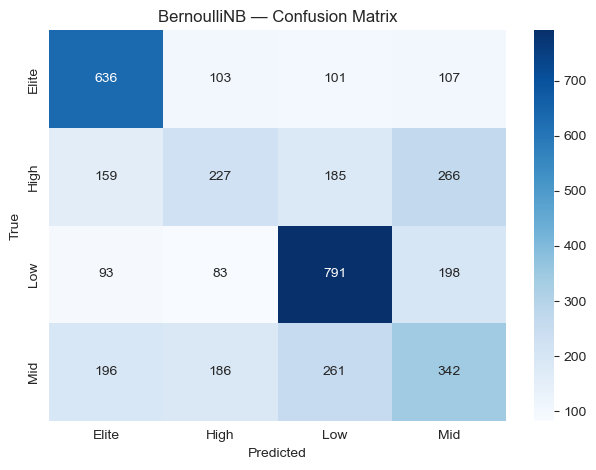

In [183]:
print("=" * 50)
print("BernoulliNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_bnb):.4f}")
print(classification_report(y_clf_test, y_bnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_bnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('BernoulliNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [184]:
cnb = ComplementNB()
cnb.fit(X_train_clf[ohe_cols], y_clf_train)
y_cnb = cnb.predict(X_test_clf[ohe_cols])

"No shifting was required since OHE features are already non-negative."

ComplementNB
Accuracy: 0.5010
              precision    recall  f1-score   support

       Elite       0.57      0.68      0.62       947
        High       0.37      0.28      0.32       837
         Low       0.58      0.67      0.63      1165
         Mid       0.38      0.32      0.35       985

    accuracy                           0.50      3934
   macro avg       0.47      0.49      0.48      3934
weighted avg       0.48      0.50      0.49      3934



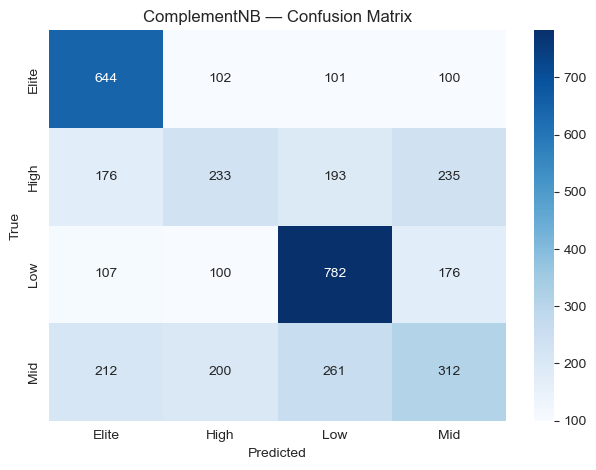

In [185]:
print("=" * 50)
print("ComplementNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_cnb):.4f}")
print(classification_report(y_clf_test, y_cnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_cnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('ComplementNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [186]:
# GaussianNB: with vs without scaling
print("=" * 50)
print("GaussianNB — Scaling Sensitivity")
print("=" * 50)

# WITHOUT scaling
gnb_unscaled = GaussianNB()
gnb_unscaled.fit(X_train_clf[nb_num_cols], y_clf_train)
acc_unscaled = accuracy_score(y_clf_test, gnb_unscaled.predict(X_test_clf[nb_num_cols]))

# WITH scaling
scaler_num = StandardScaler()
X_train_scaled = scaler_num.fit_transform(X_train_clf[nb_num_cols])
X_test_scaled  = scaler_num.transform(X_test_clf[nb_num_cols])

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_clf_train)
acc_scaled = accuracy_score(y_clf_test, gnb_scaled.predict(X_test_scaled))

print(f"GaussianNB WITHOUT scaling: {acc_unscaled:.4f}")
print(f"GaussianNB WITH scaling:    {acc_scaled:.4f}")

GaussianNB — Scaling Sensitivity
GaussianNB WITHOUT scaling: 0.7102
GaussianNB WITH scaling:    0.7102


# *Which Naïve Bayes Variant is Most Appropriate?*

GaussianNB is the most appropriate variant for this dataset.

The numerical features used (Age, Future Potential, Total_Stats Score)
are continuous variables that approximately follow a normal distribution
within each class. GaussianNB assumes exactly this — that each feature
follows a Gaussian (normal) distribution per class, making it a natural
fit for this type of data.

BernoulliNB is designed for binary (0/1) features only, which does not
match our continuous numerical features.

ComplementNB is designed for text classification tasks (e.g., word counts
in documents), and performs poorly on numerical data as confirmed by its
low accuracy (52%) and near-zero recall on High and Mid classes.

Evidence from results:
- GaussianNB  → Accuracy: 71%  (best)
- BernoulliNB → Accuracy: 30%
- ComplementNB → Accuracy: 30% (worst)

Conclusion: GaussianNB achieves the highest accuracy because its
assumptions align with the nature of the features in this dataset.

# *Scaling Sensitivity:*

GaussianNB WITHOUT scaling: 0.7102
GaussianNB WITH scaling:    0.7102

Scaling has NO effect on GaussianNB's performance.

Why? GaussianNB internally computes the mean and variance of each
feature per class. StandardScaler shifts and rescales the values,
but does NOT change the shape or relative distribution of the data
within each class. Since GaussianNB only cares about the distribution
shape (not the absolute values), the predictions remain identical
with or without scaling.

In [187]:
X_all_clf = np.vstack([X_train_clf.values, X_test_clf.values])
y_all_clf  = np.concatenate([y_clf_train, y_clf_test])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GaussianNB — best Naive Bayes variant
nb_cols_idx = [list(X_train_clf.columns).index(c) for c in nb_num_cols]
gnb_scores = []
for train_idx, val_idx in skf.split(X_all_clf, y_all_clf):
    gnb.fit(X_all_clf[train_idx][:, nb_cols_idx], y_all_clf[train_idx])
    gnb_scores.append(accuracy_score(y_all_clf[val_idx], gnb.predict(X_all_clf[val_idx][:, nb_cols_idx])))

gnb_scores = np.array(gnb_scores)
print(f"GaussianNB — Mean: {gnb_scores.mean():.4f} | Std: {gnb_scores.std():.4f}")
print(f"Individual Fold Scores: {gnb_scores}")

GaussianNB — Mean: 0.7173 | Std: 0.0052
Individual Fold Scores: [0.72750381 0.71530249 0.71599288 0.71497585 0.71268752]


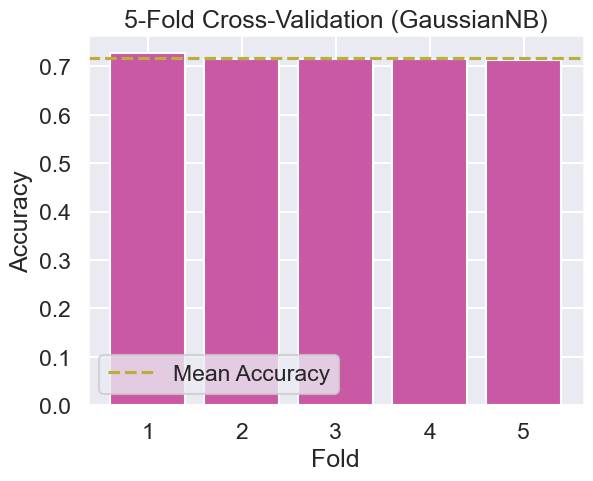

In [237]:
plt.bar(range(1, 6), gnb_scores, color="#CA59A5")
plt.axhline(gnb_scores.mean() ,color="#BDAE3C" , linestyle='--', label='Mean Accuracy')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation (GaussianNB)")
plt.legend()
plt.show()

## K-Fold

In [188]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer


In [195]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(
    lasso_best,   # Polynomial Degree 4 + Lasso
    X_train_reg,
    y_reg_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

print('RMSE Scores per fold: ')
for i,score in enumerate(rmse_scores):
    print(f"Fold {i+1 }: {score:.4f}")
    

print(f"\nMean RMSE : {rmse_scores.mean():.4f}")
print(f"Std RMSE  : {rmse_scores.std():.4f}")


RMSE Scores per fold: 
Fold 1: 4.9311
Fold 2: 5.5291
Fold 3: 4.7803
Fold 4: 4.6259
Fold 5: 5.1092

Mean RMSE : 4.9951
Std RMSE  : 0.3113


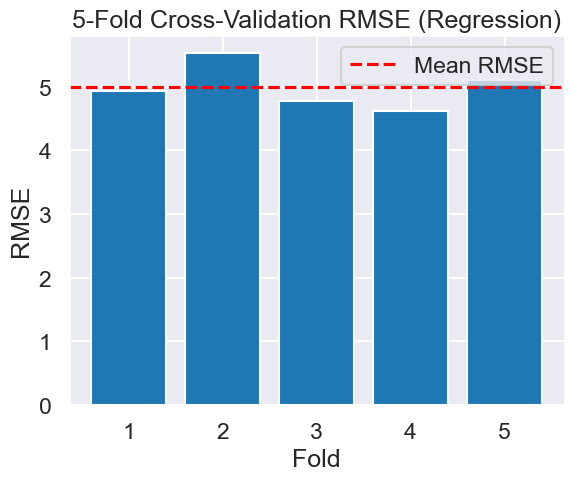

In [234]:
plt.bar(range(1, 6), rmse_scores)
plt.axhline(rmse_scores.mean() ,color='red' , linestyle='--', label='Mean RMSE')
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("5-Fold Cross-Validation RMSE (Regression)")
plt.legend()
plt.show()

## Stratified K-Fold


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score


In [205]:

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score


In [214]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(logistic_model_l1, X_train_clf, y_clf_train, cv=skf, scoring='accuracy')

accuracy_scores_l1 = skf_scores

print('Accuracy Scores per fold: \n ')
for i,score in enumerate(accuracy_scores_l1):
    print(f"Fold {i+1 }: {score:.4f}")
    
print(f"\nMean accuracy : {accuracy_scores_l1.mean():.4f}")
print(f"Std accuracy  : {accuracy_scores_l1.std():.4f}")

Accuracy Scores per fold: 
 
Fold 1: 0.8081
Fold 2: 0.8030
Fold 3: 0.7995
Fold 4: 0.7988
Fold 5: 0.8055

Mean accuracy : 0.8030
Std accuracy  : 0.0035


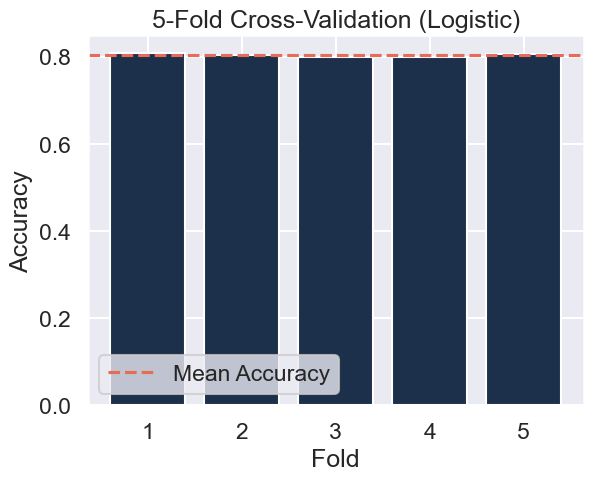

In [235]:
plt.bar(range(1, 6), skf_scores, color="#1D304B")
plt.axhline(accuracy_scores_l1.mean() ,color="#E46C59" , linestyle='--', label='Mean Accuracy')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation (Logistic)")
plt.legend()
plt.show()

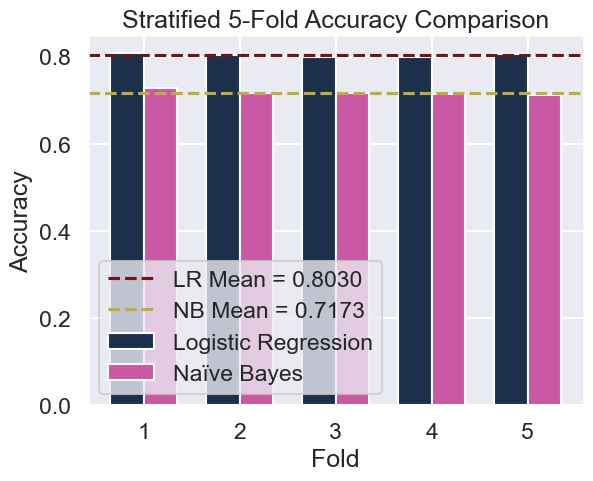

In [236]:
x = np.arange(1, 6)
width = 0.35

plt.bar(x - width/2, skf_scores, width, label="Logistic Regression", color="#1D304B")
plt.bar(x + width/2, gnb_scores, width, label="Naïve Bayes", color="#CA59A5")
plt.axhline(accuracy_scores_l1.mean(), color="#701515", linestyle='--', label=f'LR Mean = {accuracy_scores_l1.mean():.4f}')
plt.axhline(gnb_scores.mean(), color="#BDAE3C", linestyle='--', label=f'NB Mean = {gnb_scores.mean():.4f}')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Stratified 5-Fold Accuracy Comparison")
plt.legend()
plt.show()